# Clasificación de sentimientos con Naive Bayes
**Alejandro Abril — Parte 1**

Este es mi aporte al proyecto: comparar Naive Bayes con conteos de palabras (BoW) y con TF-IDF para clasificar las reseñas como positivas, negativas o neutrales.

La primera versión llegó a 72% de accuracy en validación. En esta versión pruebo si la preparación del texto que vimos en clase ayuda a mejorar ese resultado. Las tablas, la matriz de confusión y los ejemplos de errores están en este mismo notebook.

## 1. Qué voy a probar y de dónde sale

Voy a comparar **MultinomialNB y ComplementNB**, cada uno con BoW y TF-IDF. La base es el material de `MaterialDeClase-ISIS-2611/202620`: tomo la preparación del texto de P3 y la forma de entrenar, buscar parámetros y evaluar de P7 y el Laboratorio 2.

| Parte de este notebook | Material del repositorio |
|---|---|
| Minúsculas, puntuación y tokenización | P3, secciones 2.2 y 2.3 |
| Stop words en español y cuidado con “no” | P3, sección 2.4 y ejercicio 1 |
| Stemming con `SnowballStemmer("spanish")` | P3, sección 2.5, ejemplo en español |
| Comparar el texto con y sin preparación | P3, ejercicio 2 |
| Conteos de palabras y conteos binarios | P3, secciones 3.1 y 3.2 |
| Bigramas y trigramas | P3, sección 2.3 y ejercicio 3 |
| TF-IDF y frecuencia logarítmica (`sublinear_tf`) | P3, sección 4 y ejercicio 6 |
| Pipeline y búsqueda con `GridSearchCV` y `StratifiedKFold` | P7, secciones 6 y 7 |
| Comparar promedio y variación en validación cruzada | Laboratorio 2, actividad 5 |
| Reporte de clasificación, matriz de confusión y modelo guardado | P7, secciones 8 y 9 |

Para las reseñas hice algunas adaptaciones: conservo palabras de dos letras como “no”, uso el stemmer español que muestra P3 y protejo negaciones y conectores al quitar stop words. La función completa de limpieza de P3 está pensada para sus ejemplos en inglés; aquí se adapta al español y al sentimiento.

MultinomialNB y ComplementNB son los modelos que acordamos comparar en el grupo. En la carpeta 202620 no encontré una práctica específica de Naive Bayes. Sus parámetros `alpha`, `fit_prior` y `norm` se explican aquí como ajustes de estos clasificadores y se apoyan en su documentación de scikit-learn.

La división 80/20 y la semilla 42 permiten compararlo con los compañeros; las cinco particiones y los valores de búsqueda son decisiones de este experimento. Uso accuracy como métrica principal porque es la de Kaggle. El vocabulario se aprende dentro de cada partición, siguiendo la idea de incluir la preparación en el pipeline.

Los n-gramas permiten incluir expresiones cortas como “no funciona”. Eso puede ayudar con el sentimiento, aunque el modelo sigue sin entender una reseña completa. Todo se trabaja con representaciones clásicas de texto y clasificadores de scikit-learn, dentro de la Parte 1.

## 2. Antes de empezar

Los archivos `train.csv`, `eval.csv` y `sample_submission.csv` deben estar en `data/`. El notebook se puede ejecutar desde la carpeta del proyecto o desde `notebooks/`.

Las librerías están en `requirements-naive-bayes.txt`. Después de escoger el entorno de Python, hay que ejecutar las celdas en orden. La búsqueda de parámetros es la parte que más tarda; usa dos procesos. Si el computador tiene poca memoria, se puede cambiar `N_JOBS` a `1`.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
import platform

import numpy as np
import pandas as pd
import sklearn
import scipy
import joblib
from joblib import Memory, wrap_non_picklable_objects
from IPython.display import display, HTML
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from nltk.stem import SnowballStemmer
import nltk

SEMILLA = 42
N_FOLDS = 5
N_JOBS = 2
ALPHAS = [0.1, 0.5, 2.0, 5.0]
NGRAMAS = [(1, 2), (1, 3)]
MIN_DF = [1, 2, 5]

versiones = {
    "python": platform.python_version(), "scikit-learn": sklearn.__version__,
    "pandas": pd.__version__, "numpy": np.__version__,
    "scipy": scipy.__version__, "joblib": joblib.__version__, "nltk": nltk.__version__,
}
print("Versiones:", versiones)

Versiones: {'python': '3.14.2', 'scikit-learn': '1.9.0', 'pandas': '3.0.5', 'numpy': '2.5.2', 'scipy': '1.18.0', 'joblib': '1.5.3', 'nltk': '3.10.3'}


## 3. Cargar y revisar los datos

Primero reviso que estén las columnas `id`, `text` y `label`, y que no haya textos vacíos ni etiquetas extrañas. También reviso reseñas repetidas, porque una misma reseña en entrenamiento y validación haría que el resultado pareciera mejor de lo que es.

En estos datos se pudieron usar las **12.000 reseñas**: no hubo filas vacías ni textos repetidos que quitar.

In [2]:
candidatas = [Path.cwd(), Path.cwd().parent]
RAIZ = next((p for p in candidatas if (p / "notebooks/04_Naive_Bayes.ipynb").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Ejecuta desde la raíz del proyecto o desde notebooks/.")
DATA_DIR = RAIZ / "data"
ruta_train = DATA_DIR / "train.csv"
if not ruta_train.is_file():
    raise FileNotFoundError(f"Falta {ruta_train}. Descarga el train.csv de la competencia.")

CLASES = ["negativo", "neutral", "positivo"]

def validar_datos_train(datos):
    faltantes = {"id", "text", "label"} - set(datos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en train.csv: {sorted(faltantes)}")
    if datos["id"].isna().any() or datos["id"].duplicated().any():
        raise ValueError("train.csv contiene identificadores vacíos o repetidos.")
    datos = datos.copy()
    textos = datos["text"].astype("string")
    etiquetas = datos["label"].astype("string")
    validos = textos.notna() & textos.str.strip().ne("") & etiquetas.notna() & etiquetas.str.strip().ne("")
    limpieza = {"filas_originales": len(datos), "filas_vacias_excluidas": int((~validos).sum())}
    datos = datos.loc[validos].copy()
    if not datos["text"].map(lambda x: isinstance(x, str)).all():
        raise ValueError("Los textos deben ser cadenas de caracteres.")
    if set(datos["label"].unique()) != set(CLASES):
        raise ValueError(f"Se esperan las tres etiquetas exactas {CLASES}. Revisa train.csv.")
    claves = datos["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    etiquetas_por_texto = datos.groupby(claves)["label"].nunique()
    if (etiquetas_por_texto > 1).any():
        raise ValueError("Hay reseñas repetidas con etiquetas contradictorias. Revisa los datos.")
    repetidos = claves.duplicated()
    limpieza["textos_repetidos_excluidos"] = int(repetidos.sum())
    datos = datos.loc[~repetidos].reset_index(drop=True)
    if datos["label"].value_counts().min() < 10:
        raise ValueError("Se necesitan al menos 10 textos distintos por clase para esta partición y CV.")
    limpieza["filas_utilizadas"] = len(datos)
    return datos, limpieza

train, limpieza = validar_datos_train(pd.read_csv(ruta_train))
print(limpieza)
display(train.head())
display(train["label"].value_counts().reindex(CLASES))

{'filas_originales': 12000, 'filas_vacias_excluidas': 0, 'textos_repetidos_excluidos': 0, 'filas_utilizadas': 12000}


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


label
negativo    4212
neutral     3576
positivo    4212
Name: count, dtype: int64

## 4. Separar entrenamiento y validación

Uso la división 80/20 con semilla 42 para poder compararla con los otros modelos del grupo. La división es estratificada: conserva aproximadamente la proporción de cada etiqueta.

Dentro del 80% hago validación cruzada con cinco particiones. Elijo por accuracy promedio; si hay empate, uso F1 macro y luego la menor desviación entre particiones. El vectorizador se ajusta dentro de cada partición para que no vea los textos con los que se evalúa.

El 20% ya se había usado para revisar la primera versión. Por eso sirve para comparar ambas versiones, pero no cuenta como una prueba nueva independiente. Los parámetros se escogen con validación cruzada.

In [3]:
# P7, secciones 5 y 7: separación de datos y validación estratificada.
# Aquí usamos 80/20, semilla 42 y cinco particiones para el experimento del grupo.
X_train, X_val, y_train, y_val = train_test_split(
    train["text"], train["label"], test_size=0.20, random_state=SEMILLA, stratify=train["label"]
)
if y_train.value_counts().min() < N_FOLDS:
    raise ValueError("No hay suficientes ejemplos por clase para cinco folds.")
cv = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA).split(X_train, y_train))
distribucion = pd.concat([
    y_train.value_counts(normalize=True).rename("entrenamiento"),
    y_val.value_counts(normalize=True).rename("validación_reservada"),
], axis=1).reindex(CLASES)
print(f"Entrenamiento: {len(X_train)} · Validación reservada: {len(X_val)}")
display((100 * distribucion).round(2))

Entrenamiento: 9600 · Validación reservada: 2400


,entrenamiento,validación_reservada
label,,
negativo,35.09,35.12
neutral,29.80,29.79
positivo,35.10,35.08


## 5. Probar distintas formas de preparar el texto

Comparo cinco opciones: texto original, limpieza, stemming, stop words y stemming con stop words. Esta comparación retoma el ejercicio 2 de P3, donde se propone revisar el efecto de quitar o aplicar preprocesamiento. La limpieza pasa a minúsculas, separa la puntuación y quita los tokens que solo tienen números, como en la sección 2.2.

El stemming agrupa palabras con una raíz parecida, por ejemplo “funciona” y “funcionando”. Uso `SnowballStemmer("spanish")`, que aparece en el ejemplo en español de la sección 2.5 de P3.

El ejercicio 1 de P3 muestra por qué quitar “no” cambia el sentido de una frase. A partir de esa idea, conservo negaciones y palabras como “pero” y “muy”. La lista de stop words en español de NLTK queda incluida aquí para poder ejecutar sin descargarla otra vez. No quito los acentos antes de vectorizar; el stemmer sí puede cambiarlos al obtener una raíz.

Esta frase muestra cómo queda el texto con cada opción:

In [4]:
# P3, ejercicio 1: lista de stop words en español de NLTK.
STOP_WORDS_ES = ["de","la","que","el","en","y","a","los","del","se","las","por","un","para","con","no","una","su","al","lo","como","más","pero","sus","le","ya","o","este","sí","porque","esta","entre","cuando","muy","sin","sobre","también","me","hasta","hay","donde","quien","desde","todo","nos","durante","todos","uno","les","ni","contra","otros","ese","eso","ante","ellos","e","esto","mí","antes","algunos","qué","unos","yo","otro","otras","otra","él","tanto","esa","estos","mucho","quienes","nada","muchos","cual","poco","ella","estar","estas","algunas","algo","nosotros","mi","mis","tú","te","ti","tu","tus","ellas","nosotras","vosotros","vosotras","os","mío","mía","míos","mías","tuyo","tuya","tuyos","tuyas","suyo","suya","suyos","suyas","nuestro","nuestra","nuestros","nuestras","vuestro","vuestra","vuestros","vuestras","esos","esas","estoy","estás","está","estamos","estáis","están","esté","estés","estemos","estéis","estén","estaré","estarás","estará","estaremos","estaréis","estarán","estaría","estarías","estaríamos","estaríais","estarían","estaba","estabas","estábamos","estabais","estaban","estuve","estuviste","estuvo","estuvimos","estuvisteis","estuvieron","estuviera","estuvieras","estuviéramos","estuvierais","estuvieran","estuviese","estuvieses","estuviésemos","estuvieseis","estuviesen","estando","estado","estada","estados","estadas","estad","he","has","ha","hemos","habéis","han","haya","hayas","hayamos","hayáis","hayan","habré","habrás","habrá","habremos","habréis","habrán","habría","habrías","habríamos","habríais","habrían","había","habías","habíamos","habíais","habían","hube","hubiste","hubo","hubimos","hubisteis","hubieron","hubiera","hubieras","hubiéramos","hubierais","hubieran","hubiese","hubieses","hubiésemos","hubieseis","hubiesen","habiendo","habido","habida","habidos","habidas","soy","eres","es","somos","sois","son","sea","seas","seamos","seáis","sean","seré","serás","será","seremos","seréis","serán","sería","serías","seríamos","seríais","serían","era","eras","éramos","erais","eran","fui","fuiste","fue","fuimos","fuisteis","fueron","fuera","fueras","fuéramos","fuerais","fueran","fuese","fueses","fuésemos","fueseis","fuesen","sintiendo","sentido","sentida","sentidos","sentidas","siente","sentid","tengo","tienes","tiene","tenemos","tenéis","tienen","tenga","tengas","tengamos","tengáis","tengan","tendré","tendrás","tendrá","tendremos","tendréis","tendrán","tendría","tendrías","tendríamos","tendríais","tendrían","tenía","tenías","teníamos","teníais","tenían","tuve","tuviste","tuvo","tuvimos","tuvisteis","tuvieron","tuviera","tuvieras","tuviéramos","tuvierais","tuvieran","tuviese","tuvieses","tuviésemos","tuvieseis","tuviesen","teniendo","tenido","tenida","tenidos","tenidas","tened"]
PALABRAS_PROTEGIDAS = {
    "no", "ni", "sin", "nunca", "jamás", "jamas", "tampoco", "pero",
    "aunque", "sino", "muy", "más", "menos", "bien", "mal", "poco", "casi", "solo", "sólo",
}
STOP_WORDS_SEGURAS = sorted(set(STOP_WORDS_ES) - PALABRAS_PROTEGIDAS)
MODOS_TEXTO = ["original", "limpieza", "stemming", "stopwords", "stemming_stopwords"]

@wrap_non_picklable_objects
def preparar_textos(textos, modo="original", palabras_vacias=()):
    import re
    from nltk.stem import SnowballStemmer
    if modo == "original":
        return list(textos)
    if modo not in {"limpieza", "stemming", "stopwords", "stemming_stopwords"}:
        raise ValueError(f"Modo desconocido: {modo}")
    quitar_stopwords = modo in {"stopwords", "stemming_stopwords"}
    aplicar_stemming = modo in {"stemming", "stemming_stopwords"}
    # P3, sección 2.5: el ejemplo en español usa SnowballStemmer.
    stemmer = SnowballStemmer("spanish") if aplicar_stemming else None
    vacias = set(palabras_vacias)
    protegidas = {
        "no", "ni", "sin", "nunca", "jamás", "jamas", "tampoco", "pero",
        "aunque", "sino", "muy", "más", "menos", "bien", "mal", "poco", "casi", "solo", "sólo",
    }
    cache_raices, preparados = {}, []
    for texto in textos:
        tokens = re.findall(r"(?u)\b\w\w+\b", texto.lower())
        tokens = [t for t in tokens if not t.isdigit()]
        if quitar_stopwords:
            tokens = [t for t in tokens if t not in vacias or t in protegidas]
        if aplicar_stemming:
            for t in tokens:
                if t not in cache_raices:
                    cache_raices[t] = t if t in protegidas else stemmer.stem(t)
            tokens = [cache_raices[t] for t in tokens]
        preparados.append(" ".join(tokens))
    return preparados

OPCIONES_PREPARACION = [
    {"modo": modo, "palabras_vacias": STOP_WORDS_SEGURAS if "stopwords" in modo else []}
    for modo in MODOS_TEXTO
]
frase = "El producto no funciona, pero la batería estaba funcionando bien."
display(pd.DataFrame({
    "modo": MODOS_TEXTO,
    "texto_preparado": [preparar_textos([frase], **opcion)[0] for opcion in OPCIONES_PREPARACION],
}))

,modo,texto_preparado
0,original,"El producto no funciona, pero la batería estab..."
1,limpieza,el producto no funciona pero la batería estaba...
2,stemming,el product no funcion pero la bat estab funcio...
3,stopwords,producto no funciona pero batería funcionando ...
4,stemming_stopwords,product no funcion pero bat funcion bien


## 6. Buscar los parámetros

Primero vuelvo a evaluar el mejor modelo de la versión anterior. Después comparo las cuatro combinaciones con las cinco opciones de texto, unigramas con bigramas o trigramas y varios valores de `alpha`.

Por último, ajusto con más detalle las dos combinaciones que mejor salieron. Pruebo valores cercanos de `alpha`, distintos mínimos de frecuencia (`min_df`) y cambios en la ponderación de las palabras. En MultinomialNB también pruebo si conviene usar la proporción real de las clases (`fit_prior`); en ComplementNB, su opción de normalización (`norm`).

`alpha` es el suavizado: evita que una palabra no vista en una clase tenga probabilidad cero. La búsqueda se hace por etapas para no probar todas las combinaciones posibles. El modelo anterior también puede ganar si las nuevas opciones no lo mejoran.

In [5]:
familias = [
    ("BoW", "MultinomialNB"), ("BoW", "ComplementNB"),
    ("TF-IDF", "MultinomialNB"), ("TF-IDF", "ComplementNB"),
]

def crear_pipeline(representacion, modelo):
    # P3: BoW y TF-IDF; P7, sección 6: preparación y modelo en un pipeline.
    vectorizador = CountVectorizer if representacion == "BoW" else TfidfVectorizer
    clasificador = MultinomialNB(fit_prior=False) if modelo == "MultinomialNB" else ComplementNB()
    opciones_vector = {"lowercase": True, "strip_accents": None, "stop_words": None, "min_df": 1}
    if representacion == "TF-IDF":
        opciones_vector["sublinear_tf"] = True
    return Pipeline([
        ("preparacion", FunctionTransformer(
            preparar_textos, validate=False, kw_args={"modo": "original", "palabras_vacias": []},
        )),
        ("vectorizer", vectorizador(**opciones_vector)),
        ("classifier", clasificador),
    ])

def ordenar_resultados(tabla):
    return tabla.sort_values(
        ["accuracy_cv", "f1_macro_cv", "std_accuracy_cv"],
        ascending=[False, False, True], kind="stable",
    )

def seleccionar_indice(resultados_cv):
    tabla = pd.DataFrame({
        "accuracy_cv": resultados_cv["mean_test_accuracy"],
        "f1_macro_cv": resultados_cv["mean_test_f1_macro"],
        "std_accuracy_cv": resultados_cv["std_test_accuracy"],
    })
    if not np.isfinite(tabla.to_numpy()).all():
        raise ValueError("Hay métricas de CV no finitas; revisa los datos y parámetros.")
    return int(ordenar_resultados(tabla).index[0])

def ejecutar_busqueda(pipeline, rejilla, familia, etapa):
    cantidad = len(ParameterGrid(rejilla))
    print(f"{familia} · {etapa}: {cantidad} candidatos, {cantidad * N_FOLDS} ajustes", flush=True)
    with TemporaryDirectory(prefix="naive-bayes-cv-") as carpeta_cache:
        pipeline = clone(pipeline)
        pipeline.memory = Memory(carpeta_cache, verbose=0)
        # P7, sección 7: buscar parámetros dentro de la validación cruzada.
        busqueda = GridSearchCV(
            pipeline, rejilla, scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
            refit=seleccionar_indice, cv=cv, n_jobs=N_JOBS, pre_dispatch=N_JOBS,
            error_score="raise", return_train_score=True,
        )
        busqueda.fit(X_train, y_train)
        mejor = busqueda.best_estimator_
        mejor.memory = None  # El pipeline guardado no depende de la caché temporal.
        resultados = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "familia": familia, "etapa": etapa,
        "accuracy_cv": resultados["mean_test_accuracy"],
        "std_accuracy_cv": resultados["std_test_accuracy"],
        "f1_macro_cv": resultados["mean_test_f1_macro"],
        "accuracy_train_cv": resultados["mean_train_accuracy"],
        "segundos_fit_medio": resultados["mean_fit_time"],
        "parametros": resultados["params"],
    })
    tabla["brecha_train_cv"] = tabla["accuracy_train_cv"] - tabla["accuracy_cv"]
    tabla["preprocesamiento"] = tabla["parametros"].map(lambda p: p.get("preparacion__kw_args", {}).get("modo", "original"))
    fila = tabla.loc[busqueda.best_index_].to_dict()
    return mejor, tabla, fila

def rejilla_refinamiento(pipeline):
    parametros = pipeline.get_params()
    alpha = parametros["classifier__alpha"]
    rejilla = {
        "classifier__alpha": sorted({round(alpha / 3, 8), alpha, round(alpha * 3, 8)}),
        "vectorizer__ngram_range": [parametros["vectorizer__ngram_range"]],
        "vectorizer__min_df": MIN_DF,
        "preparacion__kw_args": [parametros["preparacion__kw_args"]],
    }
    if isinstance(pipeline["vectorizer"], TfidfVectorizer):
        rejilla["vectorizer__sublinear_tf"] = [False, True]
        rejilla["vectorizer__norm"] = ["l1", "l2", None]
    else:
        rejilla["vectorizer__binary"] = [False, True]
    if isinstance(pipeline["classifier"], ComplementNB):
        rejilla["classifier__norm"] = [False, True]
    else:
        rejilla["classifier__fit_prior"] = [True, False]
    return rejilla

In [6]:
tablas_cv, filas_finalistas, finalistas = [], [], {}

def registrar_candidato(modelo, tabla, fila, clave):
    tablas_cv.append(tabla)
    finalistas[clave] = modelo
    filas_finalistas.append({**fila, "clave": clave})

referencia, tabla, fila = ejecutar_busqueda(
    crear_pipeline("TF-IDF", "MultinomialNB"),
    {
        "vectorizer__ngram_range": [(1, 2)], "vectorizer__min_df": [1],
        "vectorizer__sublinear_tf": [True], "classifier__alpha": [2.0],
        "classifier__fit_prior": [False],
    },
    "TF-IDF + MultinomialNB", "referencia_anterior",
)
fila_referencia = fila.copy()
registrar_candidato(referencia, tabla, fila, "TF-IDF + MultinomialNB | referencia_anterior")

for representacion, modelo in familias:
    familia = f"{representacion} + {modelo}"
    inicial, tabla, fila = ejecutar_busqueda(
        crear_pipeline(representacion, modelo),
        {
            "preparacion__kw_args": OPCIONES_PREPARACION,
            "vectorizer__ngram_range": NGRAMAS,
            "classifier__alpha": ALPHAS,
        },
        familia, "preparacion_texto",
    )
    registrar_candidato(inicial, tabla, fila, f"{familia} | preparacion_texto")
    print(f"Mejor de {familia}: {fila['accuracy_cv']:.4f}; {fila['preprocesamiento']}", flush=True)

a_refinar = ordenar_resultados(pd.DataFrame(filas_finalistas))
a_refinar = a_refinar[a_refinar["etapa"] == "preparacion_texto"].head(2)
for _, candidato in a_refinar.iterrows():
    refinado, tabla, fila = ejecutar_busqueda(
        finalistas[candidato["clave"]], rejilla_refinamiento(finalistas[candidato["clave"]]),
        candidato["familia"], "refinamiento_texto",
    )
    registrar_candidato(refinado, tabla, fila, f"{candidato['familia']} | refinamiento_texto")

tabla_experimentos = ordenar_resultados(pd.concat(tablas_cv, ignore_index=True))
tabla_finalistas = ordenar_resultados(pd.DataFrame(filas_finalistas))
mejor_resultado = tabla_finalistas.iloc[0]
mejor_modelo = finalistas[mejor_resultado["clave"]]
print("Ganador fijado por CV:", mejor_resultado["clave"])
print("Modo de texto:", mejor_modelo["preparacion"].kw_args["modo"])
print("Parámetros:", mejor_resultado["parametros"])
display(tabla_finalistas.drop(columns=["clave"]).round(4))

TF-IDF + MultinomialNB · referencia_anterior: 1 candidatos, 5 ajustes
BoW + MultinomialNB · preparacion_texto: 40 candidatos, 200 ajustes
Mejor de BoW + MultinomialNB: 0.7110; stemming
BoW + ComplementNB · preparacion_texto: 40 candidatos, 200 ajustes
Mejor de BoW + ComplementNB: 0.6834; stemming
TF-IDF + MultinomialNB · preparacion_texto: 40 candidatos, 200 ajustes
Mejor de TF-IDF + MultinomialNB: 0.7146; stemming
TF-IDF + ComplementNB · preparacion_texto: 40 candidatos, 200 ajustes
Mejor de TF-IDF + ComplementNB: 0.7025; stemming
TF-IDF + MultinomialNB · refinamiento_texto: 108 candidatos, 540 ajustes
BoW + MultinomialNB · refinamiento_texto: 36 candidatos, 180 ajustes
Ganador fijado por CV: TF-IDF + MultinomialNB | refinamiento_texto
Modo de texto: stemming
Parámetros: {'classifier__alpha': 2.0, 'classifier__fit_prior': True, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2), 'vectorizer__norm': 'l2', 'vec

/Users/april/Uni/9 Semestre/Machine learning/MaterialDeClase-ISIS-2611/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/april/Uni/9 Semestre/Machine learning/MaterialDeClase-ISIS-2611/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,familia,etapa,accuracy_cv,std_accuracy_cv,f1_macro_cv,accuracy_train_cv,segundos_fit_medio,parametros,brecha_train_cv,preprocesamiento
5,TF-IDF + MultinomialNB,refinamiento_texto,0.7150,0.0151,0.7280,0.9043,0.0710,"{'classifier__alpha': 2.0, 'classifier__fit_pr...",0.1893,stemming
3,TF-IDF + MultinomialNB,preparacion_texto,0.7146,0.0154,0.7268,0.9050,0.0692,"{'classifier__alpha': 2.0, 'preparacion__kw_ar...",0.1904,stemming
6,BoW + MultinomialNB,refinamiento_texto,0.7117,0.0139,0.7235,0.8648,0.2351,"{'classifier__alpha': 1.66666667, 'classifier_...",0.1532,stemming
0,TF-IDF + MultinomialNB,referencia_anterior,0.7115,0.0162,0.7236,0.9107,0.3563,"{'classifier__alpha': 2.0, 'classifier__fit_pr...",0.1992,original
1,BoW + MultinomialNB,preparacion_texto,0.7110,0.0138,0.7235,0.8867,0.0683,"{'classifier__alpha': 5.0, 'preparacion__kw_ar...",0.1757,stemming
4,TF-IDF + ComplementNB,preparacion_texto,0.7025,0.0141,0.7086,0.8627,0.0701,"{'classifier__alpha': 5.0, 'preparacion__kw_ar...",0.1602,stemming
2,BoW + ComplementNB,preparacion_texto,0.6834,0.0146,0.6859,0.9280,0.1393,"{'classifier__alpha': 5.0, 'preparacion__kw_ar...",0.2446,stemming


## 7. Comparar los modelos

La primera tabla resume la mejor configuración de cada combinación. Estas métricas son de validación cruzada y sirven para comparar el aporte de Naive Bayes con los otros modelos del equipo.

La segunda tabla permite ver qué pasó al cambiar la preparación del texto. Así se puede revisar si la limpieza, el stemming o las stop words ayudaron.

In [7]:
filas_comparacion = []
for _, fila in tabla_finalistas.drop_duplicates("familia").iterrows():
    pipe = finalistas[fila["clave"]]
    p = pipe.get_params()
    filas_comparacion.append({
        "modelo": type(pipe["classifier"]).__name__,
        "representación": "TF-IDF" if isinstance(pipe["vectorizer"], TfidfVectorizer) else "BoW",
        "etapa": fila["etapa"], "preprocesamiento": pipe["preparacion"].kw_args["modo"],
        "norm_tfidf": p.get("vectorizer__norm"), "n-gramas": p["vectorizer__ngram_range"],
        "alpha": p["classifier__alpha"], "min_df": p["vectorizer__min_df"],
        "max_features": p["vectorizer__max_features"],
        "binary": p["vectorizer__binary"],
        "sublinear_tf": p.get("vectorizer__sublinear_tf"),
        "fit_prior": p["classifier__fit_prior"] if isinstance(pipe["classifier"], MultinomialNB) else None,
        "norm_complement": p.get("classifier__norm"),
        "accuracy_cv": fila["accuracy_cv"], "f1_macro_cv": fila["f1_macro_cv"],
        "std_accuracy_cv": fila["std_accuracy_cv"],
        "brecha_train_cv": fila["brecha_train_cv"],
    })
tabla_comparacion = pd.DataFrame(filas_comparacion)
columnas_resumen = [
    "modelo", "representación", "preprocesamiento", "n-gramas", "alpha",
    "min_df", "accuracy_cv", "f1_macro_cv",
]
display(tabla_comparacion[columnas_resumen].round(4))

ganancia_cv = float(mejor_resultado["accuracy_cv"] - fila_referencia["accuracy_cv"])
print(f"Mejora frente a la versión anterior: {100 * ganancia_cv:.3f} puntos porcentuales de CV.")
print("El score de Kaggle se conocerá al subir el archivo.")
tabla_preparacion = (
    tabla_experimentos[tabla_experimentos["etapa"] == "preparacion_texto"]
    .drop_duplicates(["familia", "preprocesamiento"])
    [["familia", "preprocesamiento", "accuracy_cv", "f1_macro_cv", "std_accuracy_cv"]]
)
display(tabla_preparacion.round(4))

,modelo,representación,preprocesamiento,n-gramas,alpha,min_df,accuracy_cv,f1_macro_cv
0,MultinomialNB,TF-IDF,stemming,"(1, 2)",2.0000,1,0.7150,0.7280
1,MultinomialNB,BoW,stemming,"(1, 2)",1.6667,5,0.7117,0.7235
2,ComplementNB,TF-IDF,stemming,"(1, 2)",5.0000,1,0.7025,0.7086
3,ComplementNB,BoW,stemming,"(1, 3)",5.0000,1,0.6834,0.6859


Mejora frente a la versión anterior: 0.354 puntos porcentuales de CV.
El score de Kaggle se conocerá al subir el archivo.


,familia,preprocesamiento,accuracy_cv,f1_macro_cv,std_accuracy_cv
0,TF-IDF + MultinomialNB,stemming,0.7146,0.7268,0.0154
1,TF-IDF + MultinomialNB,original,0.7115,0.7236,0.0162
2,TF-IDF + MultinomialNB,limpieza,0.7113,0.7236,0.0168
3,BoW + MultinomialNB,stemming,0.7110,0.7235,0.0138
4,BoW + MultinomialNB,limpieza,0.7103,0.7229,0.0153
5,BoW + MultinomialNB,original,0.7102,0.7227,0.0153
6,TF-IDF + MultinomialNB,stemming_stopwords,0.7050,0.7154,0.0107
7,BoW + MultinomialNB,stopwords,0.7049,0.7178,0.0051
8,TF-IDF + MultinomialNB,stopwords,0.7046,0.7153,0.0142
9,BoW + MultinomialNB,stemming_stopwords,0.7034,0.7156,0.0063


## 8. Revisar las predicciones

Ahora tomo el modelo elegido y predigo las 2.400 reseñas del 20% de validación. Comparo su accuracy con la versión anterior y reviso el F1 por clase, la matriz de confusión y algunas reseñas que clasificó mal.

También incluyo una referencia sencilla: qué pasaría si todas las predicciones fueran de la clase más frecuente. `eval.csv` todavía no se usa en esta parte.

Accuracy sobre validación reutilizada: 0.7225 · F1 macro: 0.7353
Referencia anterior: 0.7200; diferencia: 0.250 puntos.
El 20% se reutiliza respecto al experimento anterior.
Referencia de clase mayoritaria: 0.3508
Errores: 666 de 2400


,precision,recall,f1-score,support
negativo,0.6179,0.5907,0.6040,843.0000
neutral,0.9805,0.9860,0.9833,715.0000
positivo,0.6069,0.6306,0.6185,842.0000
accuracy,0.7225,0.7225,0.7225,0.7225
macro avg,0.7351,0.7358,0.7353,2400.0000
weighted avg,0.7220,0.7225,0.7221,2400.0000


Predicción,negativo,neutral,positivo
Real,,,
negativo,498,7,338
neutral,4,705,6
positivo,304,7,531


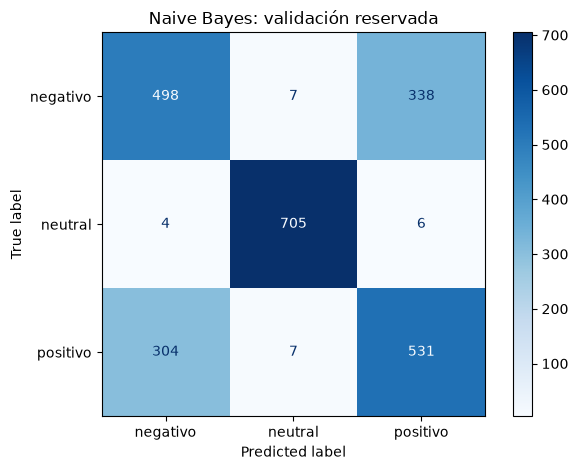

,id,texto,etiqueta_real,prediccion
10402,10402,"Lo compre hace un par de meses en una tienda por departamentos aqui cerca de casa, y lo pruebo casi todos los diias, por lo general en las noches. El sistema de carga me resulto ser terrible en estas semanas, la verdad que sin mas. Se los regale a mi hermana tambien y le llego en tres dias. Al final el tamano quedo preciso en el dia a dia.",positivo,negativo
4710,4710,"Lo pedi por internet y llego en una semana mas o menos. Hace un mes que lo estoy probando a fondo, lo uso a diario en la oficina. Por otro lado, el manual de uso se ve pesimo en general, la letra chica ni se lee bien. Pero la pantalla me salio estupenda desde el primer dia.",positivo,negativo
3875,3875,"La pedi por la pagina web un martes y llego a mi casa en cuatro dias, en una caja sencilla sin problema. La uso con un telefono que compre el ano pasado para el trabajo. La app del fabricante me parecio olvidable en mi experiencia, la abri un par de veces nomas. Con todo, la funda quedo agradable en el dia a dia.",positivo,negativo
8060,8060,"Compré este equipo a inicios de mes y llegó en tres días a mi casa. Para ser sincero, la aplicación se sintió bien hecha al final de cuentas. Lo instalé en el estudio, donde lo uso casi todas las tardes después del trabajo. Aunque al final el procesador se ve impreciso al final de cuentas.",negativo,positivo
11751,11751,"Me llegó el martes por la mañana, lo pedí desde Guadalajara y tardó como tres días en llegar. La portabilidad está muy por debajo de la media. Ya lo traigo en la mochila para la oficina, aunque la verdad se me hace incómodo de cargar. Por cierto, la cámara vale totalmente la pena. La usé el fin de semana en una reunión familiar y me lo pasó mi hermano cuando compró el suyo.",negativo,positivo
7992,7992,"Compré esto a mediados de año porque lo necesitaba para la oficina, llegó en cuatro días sin problemas de envío. El menú de ajustes resultó flojo al final de cuentas. Lo conecté en casa apenas llegó, con la conexión de 5 GHz, y la instalación no me tomó más de veinte minutos, todo según las instrucciones de la caja. La velocidad me salió muy completa la verdad.",positivo,negativo
5397,5397,"Lo pedi a principios de mes y me llego en unos cuatro dias, sin problemas. Despues de varias semanas, lo estoy usando en casa. La aplicacion quedo muy limitada a decir verdad. De ahi en fuera, el sistema de carga me resulto ser eficiente a decir verdad.",positivo,negativo
9422,9422,"La compre a inicios de mes y el envio llego en menos de tres dias, bastante rapido. Despues de varias semanas de tenerla en casa, la pruebo casi todos los dias. La uso en las tardes cuando regreso del trabajo. Todavia no le encuentro ningun detalle raro ni nada que resaltar, simplemente la uso con normalidad.",neutral,positivo
2425,2425,"Hace unos días, lo pedí en oferta. No le recomiendo el procesador a nadie. De paso, la carcasa me sorprendió para bien. Hay de todo, como se ve.",negativo,positivo
1652,1652,"Compre esta unidad a mediados de mayo y llego como en tres dias a mi casa. Doy mi punto de vista. Funciona con corriente de 120 voltios, eso lo revisamos con el electricista de mi hermano, y para ser sincero, el teclado me resulto ser mal construido a decir verdad. La use sobre todo en la oficina de mi casa, conectada al mismo enchufe de siempre. Lo que si es que, al final, el acabado se mantuvo notable en estas semanas.",positivo,negativo


In [8]:
# P7, sección 8: reporte por clase y matriz de confusión.
predicciones_val = mejor_modelo.predict(X_val)
accuracy_val = accuracy_score(y_val, predicciones_val)
f1_val = f1_score(y_val, predicciones_val, average="macro", zero_division=0)
mayoritaria = y_train.value_counts().idxmax()
accuracy_referencia = accuracy_score(y_val, np.repeat(mayoritaria, len(y_val)))
reporte = pd.DataFrame(classification_report(
    y_val, predicciones_val, labels=CLASES, output_dict=True, zero_division=0,
)).T
matriz = pd.DataFrame(
    confusion_matrix(y_val, predicciones_val, labels=CLASES),
    index=pd.Index(CLASES, name="Real"),
    columns=pd.Index(CLASES, name="Predicción"),
)
predicciones_referencia = referencia.predict(X_val)
accuracy_anterior = accuracy_score(y_val, predicciones_referencia)
print(f"Accuracy sobre validación reutilizada: {accuracy_val:.4f} · F1 macro: {f1_val:.4f}")
print(f"Referencia anterior: {accuracy_anterior:.4f}; diferencia: {100 * (accuracy_val - accuracy_anterior):.3f} puntos.")
print("El 20% se reutiliza respecto al experimento anterior.")
print(f"Referencia de clase mayoritaria: {accuracy_referencia:.4f}")
display(reporte.round(4))
display(matriz)
try:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay(matriz.to_numpy(), display_labels=CLASES).plot(cmap="Blues")
    plt.title("Naive Bayes: validación reservada")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Sin Matplotlib; la matriz está disponible en la tabla anterior.")

predicciones_validacion = pd.DataFrame({
    "id": train.loc[X_val.index, "id"], "texto": X_val,
    "etiqueta_real": y_val, "prediccion": predicciones_val,
})
errores = predicciones_validacion[
    predicciones_validacion["etiqueta_real"] != predicciones_validacion["prediccion"]
]
print(f"Errores: {len(errores)} de {len(X_val)}")
with pd.option_context("display.max_colwidth", None):
    display(errores.sample(n=min(12, len(errores)), random_state=SEMILLA))

## 9. Resumen de los resultados

La mejora fue pequeña: de **72% a 72,25%** en el mismo conjunto de validación, es decir, seis aciertos más. En validación cruzada pasó de aproximadamente **71,15% a 71,50%**.

Abajo queda la comparación entre las dos versiones. También se puede desplegar la tabla con las 305 configuraciones evaluadas, sin salir del notebook.

In [9]:
resumen_resultados = pd.DataFrame({
    "versión": ["Anterior", "Con preparación de texto"],
    "accuracy_cv": [fila_referencia["accuracy_cv"], mejor_resultado["accuracy_cv"]],
    "accuracy_validación": [accuracy_anterior, accuracy_val],
})
display(resumen_resultados.round(4))
print(f"F1 macro del modelo elegido en validación: {f1_val:.4f}")

# Dejo la búsqueda completa aquí por si necesitamos revisar algún parámetro.
detalle_experimentos = tabla_experimentos[
    ["familia", "etapa", "preprocesamiento", "accuracy_cv", "f1_macro_cv", "parametros"]
].copy()
detalle_experimentos["parametros"] = detalle_experimentos["parametros"].map(str)
display(HTML(
    f"<details><summary>Ver las {len(detalle_experimentos)} configuraciones evaluadas</summary>"
    + detalle_experimentos.round(4).to_html(index=False)
    + "</details>"
))

,versión,accuracy_cv,accuracy_validación
0,Anterior,0.7115,0.7200
1,Con preparación de texto,0.7150,0.7225


F1 macro del modelo elegido en validación: 0.7353


familia,etapa,preprocesamiento,accuracy_cv,f1_macro_cv,parametros
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7150,0.7280,"{'classifier__alpha': 2.0, 'classifier__fit_prior': True, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': False}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7149,0.7271,"{'classifier__alpha': 2.0, 'classifier__fit_prior': False, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': False}"
TF-IDF + MultinomialNB,preparacion_texto,stemming,0.7146,0.7268,"{'classifier__alpha': 2.0, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__ngram_range': [1, 2]}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7146,0.7268,"{'classifier__alpha': 2.0, 'classifier__fit_prior': False, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': True}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7146,0.7265,"{'classifier__alpha': 2.0, 'classifier__fit_prior': True, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': True}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7145,0.7275,"{'classifier__alpha': 2.0, 'classifier__fit_prior': True, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': True}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7140,0.7259,"{'classifier__alpha': 2.0, 'classifier__fit_prior': True, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': False}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7139,0.7249,"{'classifier__alpha': 2.0, 'classifier__fit_prior': False, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': True}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7137,0.7249,"{'classifier__alpha': 2.0, 'classifier__fit_prior': False, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l2', 'vectorizer__sublinear_tf': False}"
TF-IDF + MultinomialNB,refinamiento_texto,stemming,0.7125,0.7238,"{'classifier__alpha': 0.66666667, 'classifier__fit_prior': False, 'preparacion__kw_args': {'modo': 'stemming', 'palabras_vacias': []}, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': [1, 2], 'vectorizer__norm': 'l1', 'vectorizer__sublinear_tf': True}"


## 10. Guardar el modelo y preparar el envío

Para la Parte 1, la sección 4.2 del PDF pide el notebook y el modelo de scikit-learn guardado con pickle o joblib. Las tablas, la gráfica y el análisis quedan en este notebook; el modelo se guarda en `models/naive_bayes.joblib`.

Con los parámetros elegidos, entreno de nuevo con todo `train.csv`. Este pipeline incluye la preparación del texto, el vectorizador y el clasificador, así que puede recibir reseñas sin procesar.

Después predigo `eval.csv` y genero `submissions/naive_bayes.csv`, con las columnas `id` y `answer` en el orden del archivo de ejemplo. Ese CSV se sube a Kaggle. Cada ejecución reemplaza estos dos archivos con su modelo y sus predicciones.

Este es el candidato de Naive Bayes. Para entregar en Bloque Neón, el grupo debe escoger el notebook y el modelo que correspondan a su mejor envío público de Kaggle.

In [10]:
def preparar_envio(modelo, datos_eval, ejemplo=None):
    faltantes = {"id", "text"} - set(datos_eval.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en eval.csv: {sorted(faltantes)}")
    if datos_eval.empty or datos_eval["id"].isna().any() or datos_eval["id"].duplicated().any():
        raise ValueError("eval.csv está vacío o contiene IDs vacíos/repetidos.")
    if not datos_eval["text"].map(lambda x: isinstance(x, str) and bool(x.strip())).all():
        raise ValueError("eval.csv contiene textos vacíos o no textuales; revísalos sin eliminar IDs.")
    respuesta = modelo.predict(datos_eval["text"])
    if not set(respuesta).issubset(CLASES):
        raise ValueError("El modelo produjo etiquetas fuera de las clases permitidas.")
    envio = pd.DataFrame({"id": datos_eval["id"].to_numpy(), "answer": respuesta})
    if ejemplo is not None:
        if list(ejemplo.columns) != ["id", "answer"]:
            raise ValueError("El ejemplo de Kaggle debe tener las columnas id,answer.")
        if ejemplo["id"].isna().any() or ejemplo["id"].duplicated().any():
            raise ValueError("El ejemplo de Kaggle tiene IDs vacíos/repetidos.")
        if len(ejemplo) != len(envio) or set(ejemplo["id"]) != set(envio["id"]):
            raise ValueError("Los IDs del ejemplo de Kaggle no coinciden con eval.csv.")
        envio = envio.set_index("id").loc[ejemplo["id"]].reset_index()
    return envio

modelo_final = clone(mejor_modelo)
modelo_final.fit(train["text"], train["label"])
carpeta_modelos = RAIZ / "models"
carpeta_modelos.mkdir(exist_ok=True)
ruta_modelo = carpeta_modelos / "naive_bayes.joblib"
# P7, sección 9: guardar el pipeline entrenado con joblib.
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
muestra = train["text"].head(20)
if not np.array_equal(modelo_final.predict(muestra), modelo_cargado.predict(muestra)):
    raise RuntimeError("Las predicciones cambiaron al recargar el pipeline.")
print("Pipeline entrenado y guardado:", ruta_modelo)

ruta_eval = DATA_DIR / "eval.csv"
if ruta_eval.is_file():
    datos_eval = pd.read_csv(ruta_eval)
    ruta_ejemplo = next(
        (p for p in [DATA_DIR / "sample_submission.csv", DATA_DIR / "sample submission.csv"] if p.is_file()),
        None,
    )
    ejemplo = pd.read_csv(ruta_ejemplo) if ruta_ejemplo else None
    envio = preparar_envio(modelo_cargado, datos_eval, ejemplo)
    carpeta_envios = RAIZ / "submissions"
    carpeta_envios.mkdir(exist_ok=True)
    ruta_envio = carpeta_envios / "naive_bayes.csv"
    envio.to_csv(ruta_envio, index=False)
    print("Archivo listo para subir manualmente a Kaggle:", ruta_envio)
    display(envio.head())
else:
    print(f"Modelo guardado. Para generar el CSV, agrega {ruta_eval} y vuelve a ejecutar esta celda.")

Pipeline entrenado y guardado: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/models/naive_bayes.joblib
Archivo listo para subir manualmente a Kaggle: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/submissions/naive_bayes.csv


,id,answer
0,0,neutral
1,1,negativo
2,2,neutral
3,3,neutral
4,4,neutral


## 11. Qué salió de esta comparación

La mejor configuración fue **TF-IDF + MultinomialNB con stemming**, unigramas y bigramas, `alpha=2` y `min_df=1`. Usó normalización L2, frecuencia sin transformación logarítmica y las proporciones de las clases del entrenamiento. En esta búsqueda, el stemming ayudó; quitar stop words no dio el mejor resultado.

El problema más claro está entre las reseñas positivas y negativas. De las 666 equivocaciones, 338 fueron negativas clasificadas como positivas y 304 fueron positivas clasificadas como negativas. En cambio, acertó 705 de las 715 reseñas neutrales.

Hay reseñas con opiniones mezcladas. Por ejemplo, en la reseña **1043** se dice que el sonido quedó “sobresaliente”, pero que la conexión fue “lentísima”: la etiqueta es negativa y el modelo predijo positiva. En la **5049** aparece un diseño “poco fiable” y una interfaz “muy completa”: la etiqueta es positiva y el modelo predijo negativa. Estos casos sugieren que reconocer palabras positivas y negativas no basta para decidir cuál opinión pesa más en el texto.

Los bigramas ayudan a reconocer expresiones cortas, pero Naive Bayes tiene dificultades con las negaciones complejas, los contrastes y el orden de una reseña. El resultado de 72,25% deja una mejora pequeña frente a la primera versión. Falta ver el score de Kaggle y compararlo con regresión logística, SVM y SGD.

### Uso de herramientas de IA generativa

Usé Codex como apoyo para construir y revisar el notebook. Le pedí comparar las variantes de Naive Bayes, mejorarlas para Kaggle y aplicar el material del curso. La elección de Naive Bayes y la condición de usar lo visto en clase fueron decisiones mías.

Una corrección del trabajo fue escoger los parámetros por validación cruzada y aclarar que el 20% ya se había consultado. Los ejemplos de P3 fueron útiles para elegir el stemmer español y conservar negaciones. El pipeline y la validación de P7 permitieron revisar que el vocabulario se aprendiera dentro de cada partición. La ayuda de IA no reemplaza la revisión personal del código ni la explicación de los resultados en la sustentación.

### Material consultado

- [P3: preparación de textos](../../MaterialDeClase-ISIS-2611/202620/Prácticas/P3_Preparación%20de%20textos/P3_Procesamiento_de_Textos.ipynb)
- [P7: pipelines y selección de parámetros](../../MaterialDeClase-ISIS-2611/202620/Prácticas/P7_Regresión%20logística/P7_RegresionLogistica.ipynb)
- [Laboratorio 2: búsqueda de hiperparámetros](../../MaterialDeClase-ISIS-2611/202620/Laboratorios/L2/Laboratorio_2_Complejidad%20y%20búsqueda%20de%20hiperparámetros.md)
- [Documentación de Naive Bayes en scikit-learn](https://scikit-learn.org/stable/modules/naive_bayes.html)